# Web Scraping Menggunakan API Google Books

Kelompok 2 :<br>
Muhammad Refi Setyawan (159) <br>
Doni Wahana Putra (248)



Library yang dibutuhkan (jalankan sekali di sel baru jika belum tersedia):
```python
%pip install requests pandas beautifulsoup4 nltk Sastrawi demoji matplotlib wordcloud
```
Resource NLTK diunduh sekali saat blok Text Processing dijalankan.


In [ ]:
import requests
import json
import pandas as pd


## 1. Request ke Google Books API

In [ ]:
query = 'Laskar Pelangi Andrea Hirata'
api_key = 'GOOGLE BOOK API KEY'

api_url = 'https://www.googleapis.com/books/v1/volumes'
params = {'q': query, 'maxResults': 1, 'key': api_key}

response = requests.get(api_url, params=params, timeout=30)

print('Status code:', response.status_code)

data = response.json()

if response.status_code != 200 or 'error' in data:
    raise RuntimeError(data.get('error', {}).get('message', 'Google Books API gagal'))
if not data.get('items'):
    raise ValueError('Tidak ada buku yang ditemukan untuk query ini.')


Status code: 200


## 2. Melihat struktur mentah JSON


In [ ]:
item = data['items'][0]
print(json.dumps(item, indent=2, ensure_ascii=False)[:1500])


{
  "kind": "books#volume",
  "id": "S0ZNe2iqM54C",
  "etag": "s7u/fqULtvk",
  "selfLink": "https://www.googleapis.com/books/v1/volumes/S0ZNe2iqM54C",
  "volumeInfo": {
    "title": "Laskar Pelangi",
    "authors": [
      "Andrea Hirata"
    ],
    "publisher": "Bentang Pustaka",
    "publishedDate": "2008",
    "description": "Laskar Pelangi telah menjadi international best seller, diterjemahkan ke dalam 40 bahasa asing. Telah terbit dalam 22 bahasa, diedarkan di lebih dari 130 negara. Melalui program beasiswa, Hirata meraih Master of Science (M.Sc.) bidang teori ekonomi dari Sheffield Hallam University, UK. Hirata juga mendapat beasiswa pendidikan sastra di IWP (International Writing Program), University of Iowa, USA.",
    "industryIdentifiers": [
      {
        "type": "ISBN_10",
        "identifier": "9793062797"
      },
      {
        "type": "ISBN_13",
        "identifier": "9789793062792"
      }
    ],
    "readingModes": {
      "text": false,
      "image": false
    },


## 3. Ekstraksi field penting


In [ ]:
volume_info = item.get('volumeInfo', {})

book_id = item.get('id')
title = volume_info.get('title')
authors = volume_info.get('authors')
description = volume_info.get('description')
rating = volume_info.get('averageRating')
ratings_count = volume_info.get('ratingsCount')
page_count = volume_info.get('pageCount')
categories = volume_info.get('categories')
published_date = volume_info.get('publishedDate')
info_link = volume_info.get('infoLink')

print('Book ID         :', book_id)
print('Judul           :', title)
print('Penulis         :', authors)
print('Terbit          :', published_date)
print('Kategori        :', categories)
print('Jumlah halaman  :', page_count)
print('Rating          :', rating, '- dari', ratings_count, 'penilaian')
print('Link            :', info_link)
print()
print('Deskripsi       :', description)


Book ID         : S0ZNe2iqM54C
Judul           : Laskar Pelangi
Penulis         : ['Andrea Hirata']
Terbit          : 2008
Kategori        : ['Indonesian fiction']
Jumlah halaman  : 556
Rating          : 4.5 - dari 99 penilaian
Link            : http://books.google.co.id/books?id=S0ZNe2iqM54C&dq=Laskar+Pelangi+Andrea+Hirata&hl=&source=gbs_api

Deskripsi       : Laskar Pelangi telah menjadi international best seller, diterjemahkan ke dalam 40 bahasa asing. Telah terbit dalam 22 bahasa, diedarkan di lebih dari 130 negara. Melalui program beasiswa, Hirata meraih Master of Science (M.Sc.) bidang teori ekonomi dari Sheffield Hallam University, UK. Hirata juga mendapat beasiswa pendidikan sastra di IWP (International Writing Program), University of Iowa, USA.


## 4. Mengambil beberapa buku sekaligus


In [ ]:
params_multi = {'q': query, 'maxResults': 10, 'key': api_key}
response_multi = requests.get(api_url, params=params_multi, timeout=30)
data_multi = response_multi.json()
if response_multi.status_code != 200 or 'error' in data_multi:
    raise RuntimeError(data_multi.get('error', {}).get('message', 'Google Books API gagal'))

records = []
for it in data_multi.get('items', []):
    vi = it.get('volumeInfo', {})
    records.append({
        'id': it.get('id'),
        'judul': vi.get('title'),
        'penulis': vi.get('authors'),
        'deskripsi': vi.get('description'),
        'bahasa_buku': vi.get('language'),
        'rating': vi.get('averageRating'),
        'jumlah_rating': vi.get('ratingsCount'),
        'kategori': vi.get('categories'),
        'terbit': vi.get('publishedDate')
    })

print('Jumlah buku ditemukan:', len(records))


Jumlah buku ditemukan: 10


## 5. Membuat DataFrame


In [ ]:
df = pd.DataFrame(records, columns=[
    'id', 'judul', 'penulis', 'deskripsi', 'bahasa_buku',
    'rating', 'jumlah_rating', 'kategori', 'terbit'
])
df


,id,judul,penulis,deskripsi,bahasa_buku,rating,jumlah_rating,kategori,terbit
0,S0ZNe2iqM54C,Laskar Pelangi,[Andrea Hirata],Laskar Pelangi telah menjadi international bes...,id,4.5,99.0,[Indonesian fiction],2008
1,8JTTDwAAQBAJ,"Andrea Hirata, Laskar Pelangi - dalam Novel da...",[TEMPO Publishing],"Setelah novel Andrea Hirata meledak, kini sutr...",id,NaN,NaN,[Biography & Autobiography],2020-01-01
2,8InjVEJ9WD0C,Teori dan kritikan sastera,[Sohaimi Abdul Aziz],History and criticism on Malay literature.,ms,NaN,NaN,[Malay literature],2014
3,h_284i9CBlcC,Dewa Ruci,None,NaN,id,NaN,NaN,[Arts],2011
4,z4kKAQAAMAAJ,Mingguan hidup,None,NaN,id,NaN,NaN,[Church and social problems],2008
5,CXGO0HfSJ5UC,Warisan geologi Pulau Belitung,[Oki Oktariadi],"Geology of Belitung Island, Indonesia.",id,NaN,NaN,[Billiton Island (Indonesia)],2014
6,nJegcEQYtcUC,Istoriografii͡a i istochnikovedenie istorii st...,None,NaN,ru,NaN,NaN,[Africa],2011
7,TAf2hP1jsxQC,Fasilitator,None,On kindergarten and primary education in Indon...,id,NaN,NaN,"[Education, Primary]",2008
8,1kSgHfLXUp8C,Bahasa & sastra Indonesia,None,On Indonesian language and literature; papers ...,id,NaN,NaN,[Indonesia],2011
9,lVv0iyK0eEMC,MEAsia,None,NaN,id,NaN,NaN,None,2014


## Text Processing - Chapter 4



,judul,status_processing,bahasa_deskripsi,text,prepro,token_sebelum,token_setelah
0,Laskar Pelangi,diproses,id,Laskar Pelangi telah menjadi international bes...,laskar pelangi international best seller terje...,56,40
1,"Andrea Hirata, Laskar Pelangi - dalam Novel da...",diproses,id,"Setelah novel Andrea Hirata meledak, kini sutr...",novel andrea hirata ledak sutradara riri riza ...,59,44
2,Teori dan kritikan sastera,diproses,en,History and criticism on Malay literature.,histori critic malay literatur,6,4
3,Dewa Ruci,deskripsi kosong - dilewati,kosong,,,0,0
4,Mingguan hidup,deskripsi kosong - dilewati,kosong,,,0,0
5,Warisan geologi Pulau Belitung,diproses,en,"Geology of Belitung Island, Indonesia.",geolog belitung island indonesia,5,4
6,Istoriografii͡a i istochnikovedenie istorii st...,deskripsi kosong - dilewati,kosong,,,0,0
7,Fasilitator,diproses,en,On kindergarten and primary education in Indon...,kindergarten primari educ indonesia,7,4
8,Bahasa & sastra Indonesia,diproses,en,On Indonesian language and literature; papers ...,indonesian languag literatur paper seminar,9,5
9,MEAsia,deskripsi kosong - dilewati,kosong,,,0,0


,judul,clean_text,rm_stopwords,stem,lemma_en,rm_frequent_demo,rm_rare_demo
0,Laskar Pelangi,laskar pelangi telah menjadi international bes...,laskar pelangi international best seller diter...,laskar pelangi international best seller terje...,,pelangi international best seller diterjemahka...,laskar pelangi international bahasa bahasa pro...
1,"Andrea Hirata, Laskar Pelangi - dalam Novel da...",setelah novel andrea hirata meledak kini sutra...,novel andrea hirata meledak sutradara riri riz...,novel andrea hirata ledak sutradara riri riza ...,,novel andrea meledak sutradara riri riza menco...,hirata riri riza laskar pelangi belitung belit...
2,Teori dan kritikan sastera,history and criticism on malay literature,history criticism malay literature,histori critic malay literatur,history criticism malay literature,history criticism malay,literature
3,Dewa Ruci,,,,,,
4,Mingguan hidup,,,,,,
5,Warisan geologi Pulau Belitung,geology of belitung island indonesia,geology belitung island indonesia,geolog belitung island indonesia,geology belitung island indonesia,geology island,indonesia
6,Istoriografii͡a i istochnikovedenie istorii st...,,,,,,
7,Fasilitator,on kindergarten and primary education in indon...,kindergarten primary education indonesia,kindergarten primari educ indonesia,kindergarten primary education indonesia,kindergarten primary education,indonesia
8,Bahasa & sastra Indonesia,on indonesian language and literature papers o...,indonesian language literature papers seminar,indonesian languag literatur paper seminar,indonesian language literature paper seminar,indonesian language papers seminar,literature
9,MEAsia,,,,,,


Record sumber: 10
Deskripsi tersedia: 6
Deskripsi kosong: 4
Deskripsi unik: 6


,bahasa,kata,frekuensi
0,en,indonesia,2
1,en,literature,2
2,en,belitung,1
3,en,criticism,1
4,en,education,1
5,en,geology,1
6,en,history,1
7,en,indonesian,1
8,en,island,1
9,en,kindergarten,1


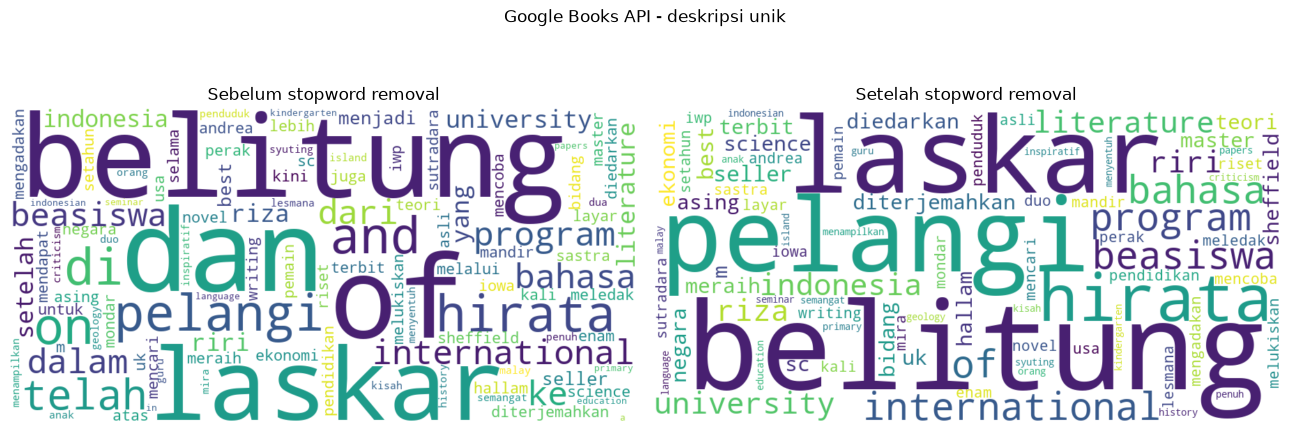

CSV hasil tersimpan: hasil_text_processing_api


In [ ]:
# Seluruh proses Chapter 4 dijadikan satu blok dan memakai df hasil scraping di atas.
from pathlib import Path
from collections import Counter
import os
import re
import json
import unicodedata
import pandas as pd
from bs4 import BeautifulSoup
import demoji
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from IPython.display import display

METHOD = 'API'
output_dir = Path.cwd() / ('hasil_text_processing_' + METHOD.lower())
output_dir.mkdir(exist_ok=True)
nltk_dir = Path(os.environ.get('NLTK_DATA', str(Path.cwd() / '.nltk_data')))
nltk_dir.mkdir(parents=True, exist_ok=True)
if str(nltk_dir) not in nltk.data.path:
    nltk.data.path.insert(0, str(nltk_dir))
for resource, locator in {
    'stopwords': 'corpora/stopwords', 'wordnet': 'corpora/wordnet',
    'averaged_perceptron_tagger_eng': 'taggers/averaged_perceptron_tagger_eng',
}.items():
    try:
        nltk.data.find(locator)
    except LookupError:
        try:
            nltk.data.find(locator + '.zip')
        except LookupError:
            if not nltk.download(resource, download_dir=str(nltk_dir), quiet=True):
                raise RuntimeError('Gagal mengunduh resource NLTK: ' + resource)

if 'deskripsi' not in df.columns:
    raise ValueError('Jalankan scraping dan pembuatan DataFrame terlebih dahulu.')
df_processed = df.copy()
df_processed['metode'] = METHOD
df_processed['text'] = df_processed['deskripsi'].fillna('').astype(str).str.strip()
df_processed['status_processing'] = df_processed['text'].map(
    lambda value: 'diproses' if value else 'deskripsi kosong - dilewati')

def remove_html(value):
    parsed = BeautifulSoup(str(value), 'html.parser')
    for tag in parsed(['script', 'style']):
        tag.decompose()
    return unicodedata.normalize('NFKC', parsed.get_text(' ', strip=True))

def remove_urls_email(value):
    value = re.sub(r'\b(?:https?://|www\.)\S+', ' ', value)
    return re.sub(r'\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b', ' ', value, flags=re.I)

def remove_emoji_emoticon(value):
    value = demoji.replace(value, ' ')
    return re.sub(r'(?::|;|=|8)[\-^]?[)(/\\|DPpOo]+', ' ', value)

def remove_punctuation(value):
    return ''.join(' ' if unicodedata.category(char)[0] in {'P', 'S'} else char
                   for char in value)

def normalize_space(value):
    return re.sub(r'\s+', ' ', value).strip()

df_processed['rm_html'] = df_processed['text'].map(remove_html)
df_processed['rm_hashtag'] = df_processed['rm_html'].map(lambda x: re.sub(r'#\w+', ' ', x))
df_processed['lower_case'] = df_processed['rm_hashtag'].str.lower()
df_processed['rm_url_email'] = df_processed['lower_case'].map(remove_urls_email)
df_processed['rm_emoji'] = df_processed['rm_url_email'].map(remove_emoji_emoticon)
df_processed['rm_punc'] = df_processed['rm_emoji'].map(remove_punctuation)
df_processed['rm_number'] = df_processed['rm_punc'].map(lambda x: re.sub(r'\d+', ' ', x))
df_processed['clean_text'] = df_processed['rm_number'].map(normalize_space)
df_processed['tokens'] = df_processed['clean_text'].str.split()

# Bahasa buku dari API dapat berbeda dengan bahasa teks deskripsinya.
# Bandingkan kata fungsi en/id; jika tidak ada petunjuk, gunakan metadata.
sw = {language: set(stopwords.words(name)) for language, name in
      [('en', 'english'), ('id', 'indonesian')]}
negations = {'en': {'no', 'not', 'nor'}, 'id': {'tidak', 'bukan', 'belum', 'jangan'}}

def choose_language(row):
    if not row['tokens']:
        return 'kosong'
    scores = {language: sum(t in words for t in row['tokens']) for language, words in sw.items()}
    if scores['en'] > scores['id']:
        return 'en'
    if scores['id'] > scores['en']:
        return 'id'
    hint = row.get('bahasa_buku', '')
    return hint if hint in sw else 'lainnya'

df_processed['bahasa_deskripsi'] = df_processed.apply(choose_language, axis=1)
filtered_sw = {language: words - negations[language] for language, words in sw.items()}
df_processed['tokens_no_stopwords'] = df_processed.apply(
    lambda row: [t for t in row['tokens']
                 if t not in filtered_sw.get(row['bahasa_deskripsi'], set())], axis=1)
df_processed['rm_stopwords'] = df_processed['tokens_no_stopwords'].map(' '.join)
porter = PorterStemmer()
id_stemmer = StemmerFactory().create_stemmer()
lemmatizer = WordNetLemmatizer()

def stem_row(row):
    if row['bahasa_deskripsi'] == 'en':
        return ' '.join(porter.stem(t) for t in row['tokens_no_stopwords'])
    if row['bahasa_deskripsi'] == 'id':
        return id_stemmer.stem(row['rm_stopwords'])
    return row['rm_stopwords']

def lemma_row(row):
    if row['bahasa_deskripsi'] != 'en':
        return ''  # WordNet Inggris tidak diterapkan pada bahasa lain.
    mapping = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
    lemmas = [lemmatizer.lemmatize(t, mapping.get(tag[0], wordnet.NOUN))
              for t, tag in nltk.pos_tag(row['tokens'])]
    return ' '.join(t for t in lemmas if t not in filtered_sw['en'])

df_processed['stem'] = df_processed.apply(stem_row, axis=1)
df_processed['lemma_en'] = df_processed.apply(lemma_row, axis=1)
df_processed['prepro'] = df_processed['stem']
df_processed['token_sebelum'] = df_processed['text'].map(lambda x: len(x.split()))
df_processed['token_setelah'] = df_processed['prepro'].map(lambda x: len(x.split()))

# Filter frequent/rare hanya contoh: jangan menghilangkan istilah penting pada korpus kecil.
unique = df_processed.loc[df_processed['clean_text'].ne('')].drop_duplicates('clean_text')
language_counts = {language: Counter(t for tokens in group['tokens_no_stopwords'] for t in tokens)
                   for language, group in unique.groupby('bahasa_deskripsi')}
top_words = {language: set(w for w, count in sorted(counts.items(), key=lambda x: (-x[1], x[0]))[:3])
             for language, counts in language_counts.items()}
rare_words = {language: {w for w, count in counts.items() if count == 1}
              for language, counts in language_counts.items()}
for column, word_sets in [('rm_frequent_demo', top_words), ('rm_rare_demo', rare_words)]:
    df_processed[column] = df_processed.apply(
        lambda row: ' '.join(t for t in row['tokens_no_stopwords']
                             if t not in word_sets.get(row['bahasa_deskripsi'], set())), axis=1)
freq_records = [{'bahasa': language, 'kata': word, 'frekuensi': count}
                for language, counts in language_counts.items()
                for word, count in sorted(counts.items(), key=lambda x: (-x[1], x[0]))]
df_frequency = pd.DataFrame(freq_records, columns=['bahasa', 'kata', 'frekuensi'])

display(df_processed[['judul', 'status_processing', 'bahasa_deskripsi', 'text',
                      'prepro', 'token_sebelum', 'token_setelah']])
display(df_processed[['judul', 'clean_text', 'rm_stopwords', 'stem', 'lemma_en',
                      'rm_frequent_demo', 'rm_rare_demo']])
print('Record sumber:', len(df_processed))
print('Deskripsi tersedia:', int(df_processed['text'].ne('').sum()))
print('Deskripsi kosong:', int(df_processed['text'].eq('').sum()))
print('Deskripsi unik:', len(unique))
display(df_frequency.head(15))

before = Counter(t for tokens in unique['tokens'] for t in tokens)
after = Counter(t for tokens in unique['tokens_no_stopwords'] for t in tokens)
if after:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, counts, label in zip(axes, [before, after],
                                ['Sebelum stopword removal', 'Setelah stopword removal']):
        cloud = WordCloud(width=900, height=450, background_color='white',
                          random_state=42, collocations=False).generate_from_frequencies(counts)
        ax.imshow(cloud, interpolation='bilinear')
        ax.set_title(label)
        ax.axis('off')
    fig.suptitle('Google Books ' + METHOD + ' - deskripsi unik')
    fig.tight_layout()
    fig.savefig(output_dir / 'wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Tidak ada token untuk visualisasi.')

export = df_processed.copy()
for column in ['tokens', 'tokens_no_stopwords']:
    export[column] = export[column].map(lambda tokens: json.dumps(tokens, ensure_ascii=False))
export.to_csv(output_dir / ('google_books_' + METHOD.lower() + '_preprocessed.csv'),
              index=False, encoding='utf-8-sig')
df_frequency.to_csv(output_dir / 'frekuensi_kata.csv', index=False, encoding='utf-8-sig')
print('CSV hasil tersimpan:', output_dir.name)
